chargement des librairies presentes dans le fichier src/imports.py

In [2]:
import sys
sys.path.append('..')
from src.imports import *

chargement du dataset

In [3]:
df = pd.read_csv("data/raw/cybersecurity_intrusion_data.csv")

apercu du dataset

In [4]:
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


taille du dataset

In [5]:
df.shape

(9537, 11)

types de variables dans le dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


pourcentages des variables manquantes 

In [7]:
((df.isnull().sum()/len(df))*100).sort_values(ascending=False)

encryption_used        20.614449
network_packet_size     0.000000
session_id              0.000000
protocol_type           0.000000
login_attempts          0.000000
session_duration        0.000000
ip_reputation_score     0.000000
failed_logins           0.000000
browser_type            0.000000
unusual_time_access     0.000000
attack_detected         0.000000
dtype: float64

verification des doublons 

In [8]:
df.duplicated().sum()

np.int64(0)

pourcentages de repartition de la variables cible

In [9]:
(df["attack_detected"].value_counts()/len(df))*100  

attack_detected
0    55.289923
1    44.710077
Name: count, dtype: float64

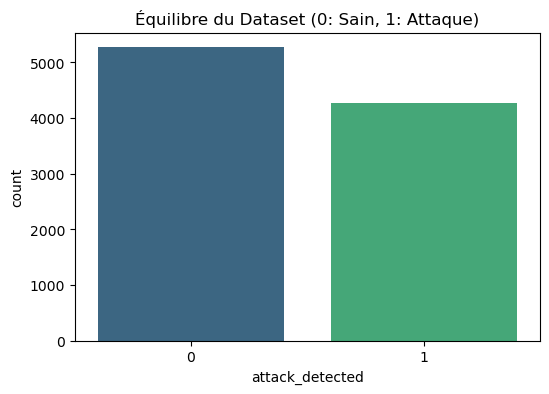

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='attack_detected', data=df, hue='attack_detected', palette='viridis', legend=False)
plt.title("Équilibre du Dataset (0: Sain, 1: Attaque)")
plt.show()

Statistiques descriptives

In [10]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


recuperation des collones numeriques 

In [11]:
colonne_numerique = df.select_dtypes(include=['number']).columns

recuperation des collones categorielles 

In [11]:
colonne_categorielle = df.select_dtypes(include=['object']).columns

Analyse des variables catégorielles

In [12]:
for i in colonne_categorielle:
    print(df[i].value_counts())

session_id
SID_09537    1
SID_09521    1
SID_09520    1
SID_09519    1
SID_09518    1
            ..
SID_00006    1
SID_00005    1
SID_00004    1
SID_00003    1
SID_00002    1
Name: count, Length: 9537, dtype: int64
protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64
encryption_used
AES    4706
DES    2865
Name: count, dtype: int64
browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64


Distribution des variables numériques

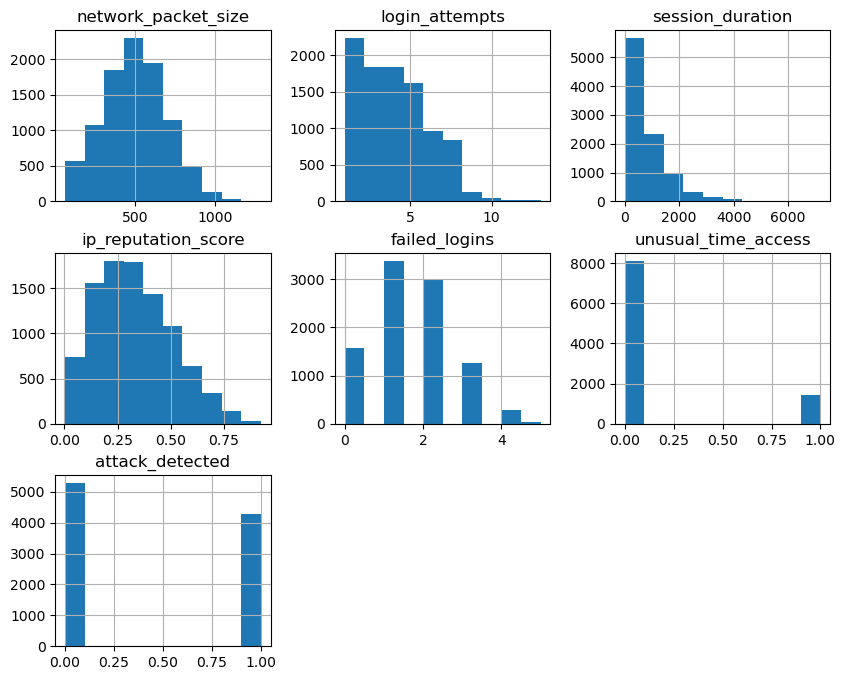

In [13]:
df.hist(figsize=(10,8))
plt.show()

Détection des outliers

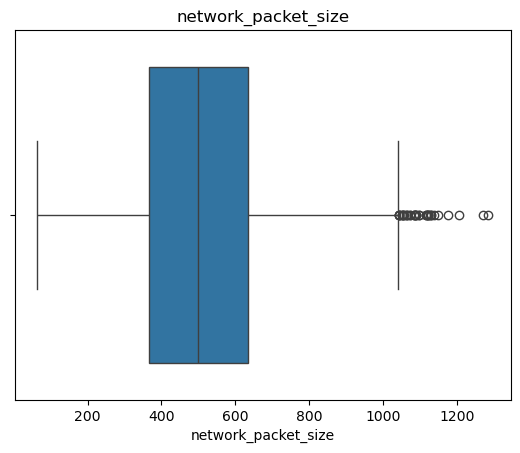

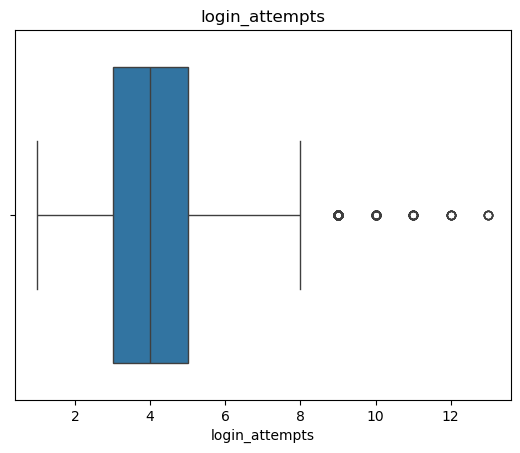

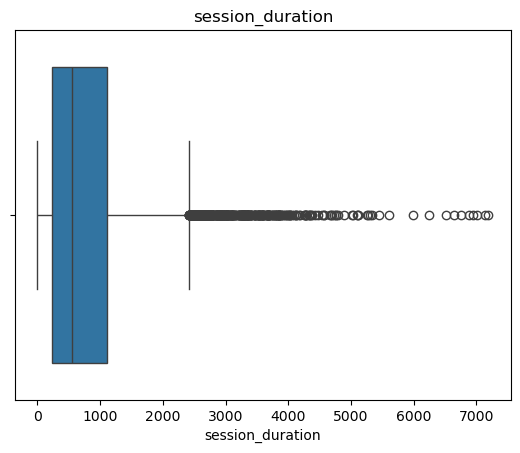

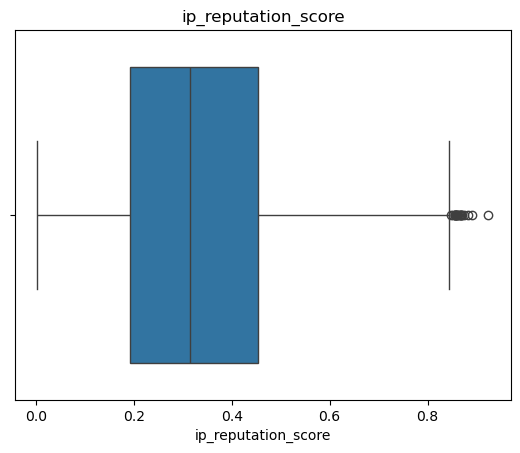

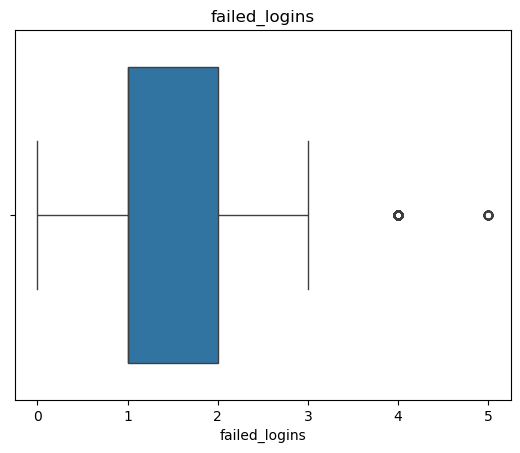

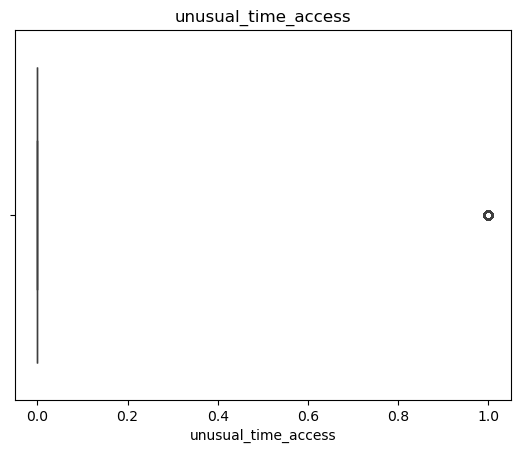

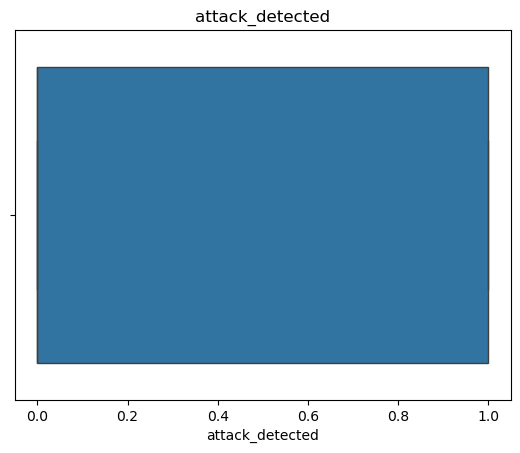

In [14]:
for col in colonne_numerique:
    plt.figure()  # 👈 très important
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Analyse des corrélations

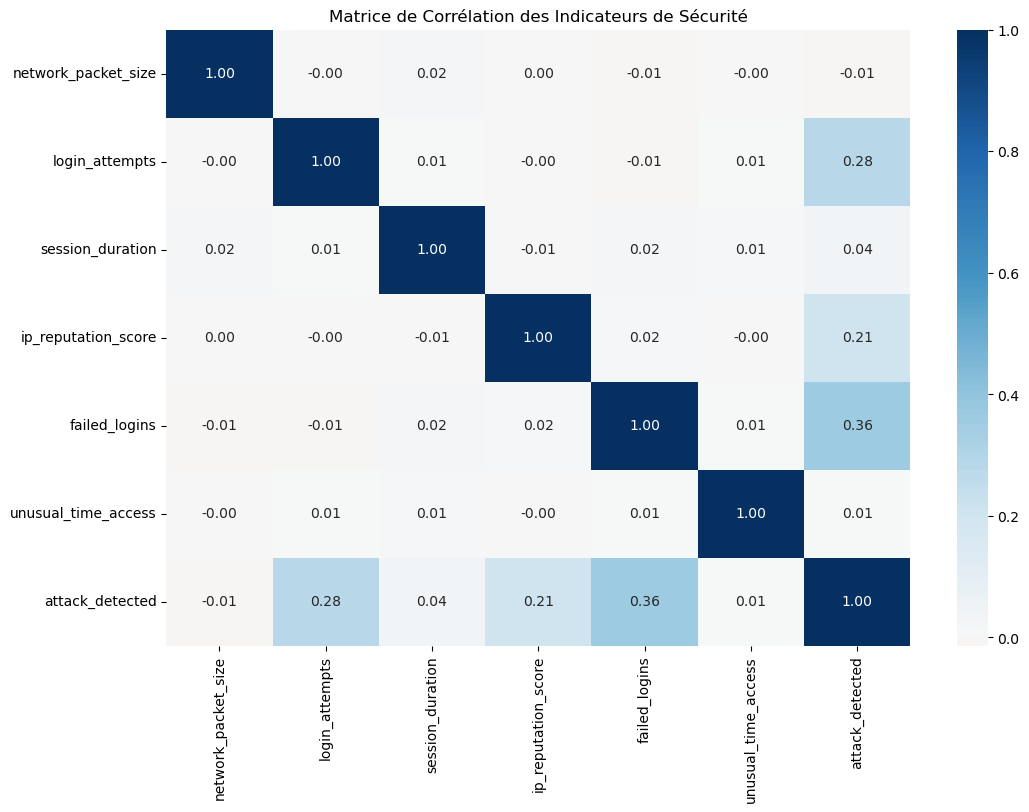

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title("Matrice de Corrélation des Indicateurs de Sécurité")
plt.show()

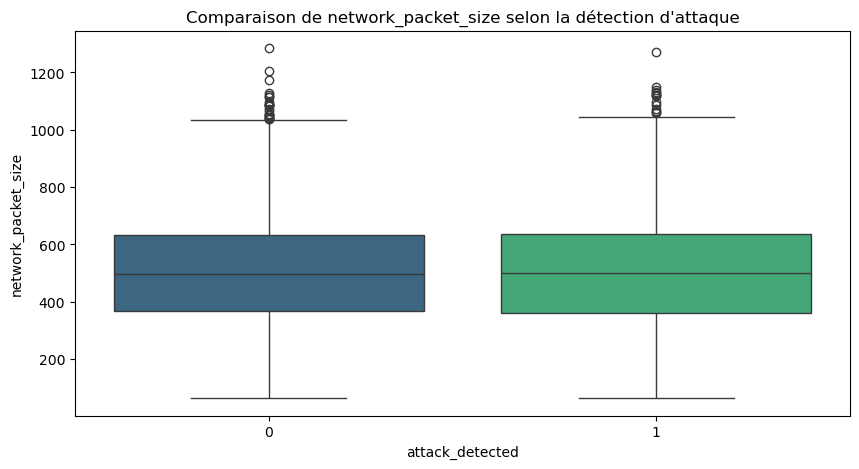

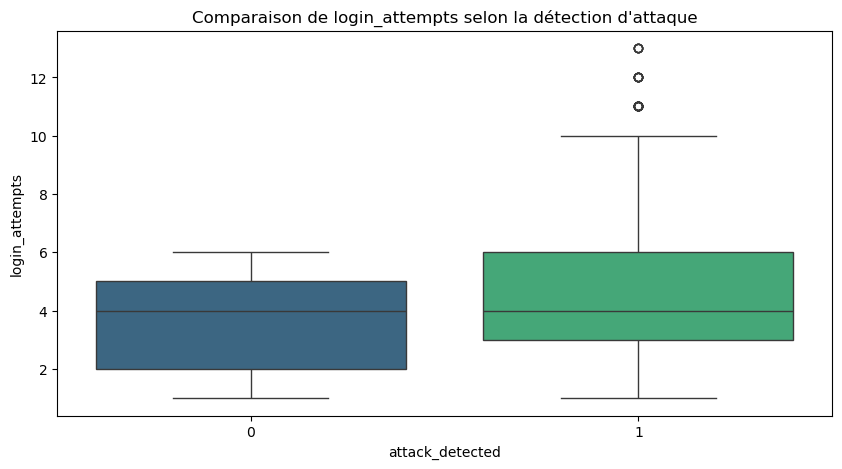

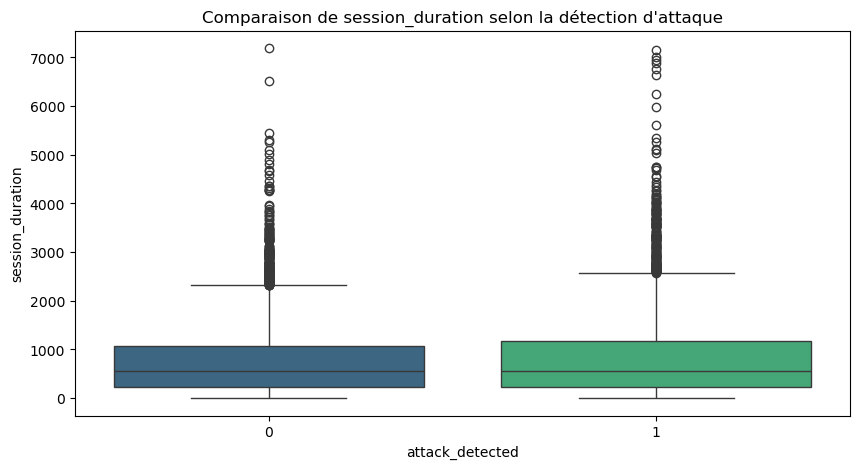

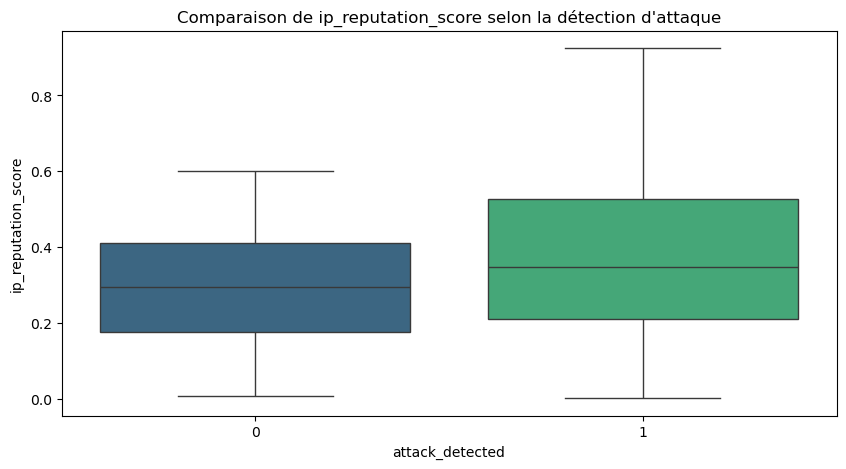

In [20]:
for col in ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score']:
    plt.figure(figsize=(10, 5))
    # On ajoute x='attack_detected' pour comparer le trafic sain (0) et les attaques (1)
    sns.boxplot(data=df, x='attack_detected', y=col, hue='attack_detected', palette='viridis', legend=False)
    plt.title(f"Comparaison de {col} selon la détection d'attaque")
    plt.show()